In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
%pip install --upgrade torch-geometric-signed-directed networkx

  Using cached torch_geometric_signed_directed-1.1.1-py3-none-any.whl.metadata (27 kB)
  Using cached torch_geometric-2.8.0.post1-py3-none-any.whl.metadata (64 kB)
  Using cached xxhash-4.0.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (17 kB)
Using cached torch_geometric_signed_directed-1.1.1-py3-none-any.whl (119 kB)
Using cached torch_geometric-2.8.0.post1-py3-none-any.whl (1.3 MB)
Using cached xxhash-4.0.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (268 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torch-geometric-signed-directed]c-signed-directed]
Note: you may need to restart the kernel to use updated packages.


In [4]:
# dbutils.library.restartPython()

In [5]:
import os

# ============================================================
# Parameters
# ============================================================
N_USERS = 8  # Total users to sample (proportionally across groups). None = all users.
EXPERIMENT_TAG = "v3_full"  # Experiment identifier
# RESTART_EXPERIMENT = True  # Set True to wipe ALL cached results/checkpoints and re-run from scratch
RESTART_EXPERIMENT = False  # Set True to wipe ALL cached results/checkpoints and re-run from scratch

# Paths
sources_path = "/serafin/pcelayes/repos/sna_classifier/"
# DATA_PATH = "/Workspace/Users/pablo.celayes@bolt.eu/learning/data/sna_classifier"
DATA_PATH = "/serafin/pcelayes/repos/sna_classifier/data"
EMBEDDINGS_PATH = f"{DATA_PATH}/node_embeddings.pt"

# Derived experiment folder
FINAL_TAG = f"{EXPERIMENT_TAG}_N{N_USERS}" if N_USERS else EXPERIMENT_TAG
EXPERIMENT_DIR = f"./experiments/{FINAL_TAG}"
os.makedirs(EXPERIMENT_DIR, exist_ok=True)
# Storage mode: True = S3, False = local subfolder in EXPERIMENT_DIR
# USE_S3_STORAGE = True
USE_S3_STORAGE = False

# S3 paths for GNN sample cache
S3_GNN_BUCKET = "pablocelayes-test"
S3_GNN_PREFIX = f"learning/sna-classifier-gnn/{FINAL_TAG}/gnn_samples"
S3_GNN_PATH = f"s3://{S3_GNN_BUCKET}/{S3_GNN_PREFIX}"

# Local path for GNN sample cache (used when USE_S3_STORAGE=False)
LOCAL_GNN_PATH = f"{EXPERIMENT_DIR}/gnn_samples"
os.makedirs(LOCAL_GNN_PATH, exist_ok=True)

# Resolved storage path (for display)
GNN_CACHE_PATH = S3_GNN_PATH if USE_S3_STORAGE else LOCAL_GNN_PATH

print(f"Experiment: {FINAL_TAG}")
print(f"Output dir: {EXPERIMENT_DIR}")
print(f"GNN cache:  {GNN_CACHE_PATH} ({'S3' if USE_S3_STORAGE else 'local'})")

Experiment: v3_full_N8
Output dir: ./experiments/v3_full_N8
GNN cache:  ./experiments/v3_full_N8/gnn_samples (local)


In [6]:
import shutil

if RESTART_EXPERIMENT:
    print("⚠️  RESTART_EXPERIMENT=True — wiping all cached results and checkpoints...")
    deleted = []

    # 1. Delete baseline results explicitly (also caught by the sweep below)
    baseline_path = f"{EXPERIMENT_DIR}/baseline_svc_results.pkl"
    if os.path.exists(baseline_path):
        os.remove(baseline_path)
        deleted.append(baseline_path)

    # 2. Delete all remaining local experiment directory contents (user_sample, checkpoints, logs)
    if os.path.isdir(EXPERIMENT_DIR):
        for item in os.listdir(EXPERIMENT_DIR):
            item_path = os.path.join(EXPERIMENT_DIR, item)
            if item_path in deleted:
                continue
            if os.path.isdir(item_path):
                shutil.rmtree(item_path)
            else:
                os.remove(item_path)
            deleted.append(item_path)

    # 3. Delete S3 GNN sample cache (if using S3 storage)
    if USE_S3_STORAGE:
        import s3fs
        fs = s3fs.S3FileSystem()
        s3_prefix = f"{S3_GNN_BUCKET}/{S3_GNN_PREFIX}"
        for s3_dir in [s3_prefix, f"{s3_prefix}_failed_users"]:
            if fs.exists(s3_dir):
                fs.rm(s3_dir, recursive=True)
                deleted.append(f"s3://{s3_dir}")
        del fs

    # 4. Delete local GNN cache (if using local storage)
    if not USE_S3_STORAGE and os.path.isdir(LOCAL_GNN_PATH):
        shutil.rmtree(LOCAL_GNN_PATH)
        deleted.append(LOCAL_GNN_PATH)
        os.makedirs(LOCAL_GNN_PATH, exist_ok=True)

    # Recreate empty experiment dir
    os.makedirs(EXPERIMENT_DIR, exist_ok=True)
    os.makedirs(LOCAL_GNN_PATH, exist_ok=True)

    print(f"  Deleted {len(deleted)} items:")
    for d in deleted:
        print(f"    - {d}")
    print("\n  Experiment reset complete. All cells will recompute from scratch.")
else:
    print("RESTART_EXPERIMENT=False — using cached results where available.")

RESTART_EXPERIMENT=False — using cached results where available.


In [20]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import sys
import json
import logging
import warnings
from random import sample, shuffle

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.utils.class_weight import compute_class_weight
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import TransformerConv
from torch_geometric_signed_directed.nn.directed import MagNetConv
import networkx as nx

warnings.filterwarnings('ignore')
logging.getLogger("py4j").setLevel(logging.ERROR)
logging.getLogger("py4j.clientserver").setLevel(logging.ERROR)

logger = logging.getLogger()
logger.setLevel(logging.INFO)
if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setLevel(logging.INFO)
    logger.addHandler(handler)

sys.path.insert(0, str(sources_path))

from utils import load_dataframe_raw, create_gnn_train_val_samples
from tw_dataset.settings import IG_GRAPH_PATH

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [8]:
graph = nx.read_graphml(IG_GRAPH_PATH)
print(f"Graph loaded: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

Graph loaded: 5589 nodes, 261005 edges


In [9]:
# Load user splits
with open(f"{DATA_PATH}/datasets/user_splits.json") as f:
    user_splits = json.load(f)

print(f"Groups in user_splits: {list(user_splits.keys())}")
for k, v in user_splits.items():
    print(f"  {k}: {len(v)} users")

# Define train groups vs test groups
TRAIN_GROUPS = ["u_train", "au_train"]
TEST_GROUPS = [g for g in user_splits.keys() if g not in TRAIN_GROUPS]
print(f"\nTrain groups: {TRAIN_GROUPS}")
print(f"Test groups: {TEST_GROUPS}")

# ---------------------------------------------------------------
# Deterministic sample tied to FINAL_TAG: save/load sampled user IDs
# so that re-runs for the same experiment tag use the exact same users.
# ---------------------------------------------------------------
SAMPLE_PATH = f"{EXPERIMENT_DIR}/user_sample.json"

if os.path.exists(SAMPLE_PATH):
    # --- FAST PATH: load previously saved sample for this tag ---
    with open(SAMPLE_PATH) as f:
        saved_sample = json.load(f)  # {group: [uid, uid, ...]}
    print(f"\nLoading saved user sample from {SAMPLE_PATH}")

    user_data = {}  # group -> uid -> (X_tr, X_te, y_tr, y_te)
    failed_users = []
    for group, uids in saved_sample.items():
        user_data[group] = {}
        for uid in uids:
            try:
                data = load_dataframe_raw(uid, sparse=True)
                X_tr, X_te, y_tr, y_te = data
                if X_tr.shape[0] > 0 and X_te.shape[0] > 0 and y_tr.sum() > 0 and y_te.sum() > 0:
                    user_data[group][uid] = (X_tr, X_te, y_tr, y_te)
                else:
                    failed_users.append((group, uid, "empty data on reload"))
            except Exception as e:
                failed_users.append((group, uid, str(e)))

    print(f"  Loaded users per group:")
    for group in saved_sample:
        print(f"    {group}: {len(user_data[group])}/{len(saved_sample[group])}")
    print(f"  Total: {sum(len(user_data[g]) for g in user_data)}")
    if failed_users:
        print(f"  Failed on reload: {len(failed_users)}")

else:
    # --- FIRST RUN: load all users, sample, then save ---
    print(f"\nNo saved sample for {FINAL_TAG}, loading all users...")
    user_data = {}  # group -> uid -> (X_tr, X_te, y_tr, y_te)
    failed_users = []

    for group in user_splits:
        user_data[group] = {}
        group_uids = user_splits[group]
        for uid in group_uids:
            try:
                data = load_dataframe_raw(uid, sparse=True)
                X_tr, X_te, y_tr, y_te = data
                if X_tr.shape[0] > 0 and X_te.shape[0] > 0 and y_tr.sum() > 0 and y_te.sum() > 0:
                    user_data[group][uid] = (X_tr, X_te, y_tr, y_te)
                else:
                    failed_users.append((group, uid, "empty data"))
            except Exception as e:
                failed_users.append((group, uid, str(e)))
                continue

    print(f"\nLoaded users per group:")
    total_valid = 0
    for group in user_splits:
        n = len(user_data[group])
        total_valid += n
        print(f"  {group}: {n}/{len(user_splits[group])} valid")
    print(f"  Total valid: {total_valid}")
    print(f"  Failed: {len(failed_users)}")

    # Proportional sampling if N_USERS is set
    if N_USERS is not None:
        group_sizes = {g: len(user_data[g]) for g in user_splits}
        total_available = sum(group_sizes.values())

        # Step 1: Keep proportions between train and test groups
        train_available = sum(group_sizes.get(g, 0) for g in TRAIN_GROUPS)
        test_available = sum(group_sizes.get(g, 0) for g in TEST_GROUPS)
        train_slots = int(round(N_USERS * train_available / total_available))
        test_slots = N_USERS - train_slots

        # Step 2: Train groups — prioritize u_train first, fill remainder with au_train
        n_u_train = min(group_sizes.get("u_train", 0), train_slots)
        n_au_train = min(group_sizes.get("au_train", 0), train_slots - n_u_train)
        raw_alloc = {"u_train": n_u_train, "au_train": n_au_train}

        # Step 3: Test groups — proportional allocation within test slots
        test_group_sizes = {g: group_sizes.get(g, 0) for g in TEST_GROUPS if group_sizes.get(g, 0) > 0}
        total_test_available = sum(test_group_sizes.values())
        for g in TEST_GROUPS:
            if total_test_available > 0 and group_sizes.get(g, 0) > 0:
                raw_alloc[g] = int(round(test_slots * group_sizes[g] / total_test_available))
            else:
                raw_alloc[g] = 0
        # Adjust test rounding to hit exact test_slots
        test_diff = test_slots - sum(raw_alloc.get(g, 0) for g in TEST_GROUPS)
        for g in sorted(TEST_GROUPS, key=lambda g: group_sizes.get(g, 0), reverse=True):
            if test_diff == 0:
                break
            adjustment = 1 if test_diff > 0 else -1
            raw_alloc[g] = max(1, raw_alloc[g] + adjustment)
            test_diff -= adjustment

        # Sample from each group
        sampled_user_data = {}
        for g in user_splits:
            if g not in raw_alloc or raw_alloc[g] == 0:
                sampled_user_data[g] = {}
                continue
            uids = list(user_data[g].keys())
            n_sample = min(raw_alloc[g], len(uids))
            sampled_uids = sample(uids, n_sample)
            sampled_user_data[g] = {uid: user_data[g][uid] for uid in sampled_uids}
        user_data = sampled_user_data

        print(f"\nSampled {N_USERS} users (train priority: u_train first, then au_train):")
        for g in user_splits:
            print(f"  {g}: {len(user_data[g])} (target {raw_alloc.get(g, 0)})")
        print(f"  Total sampled: {sum(len(user_data[g]) for g in user_splits)}")

    # Save the sample (user IDs per group) for reproducibility
    sample_to_save = {g: list(user_data[g].keys()) for g in user_data}
    with open(SAMPLE_PATH, "w") as f:
        json.dump(sample_to_save, f, indent=2)
    print(f"  Saved user sample to {SAMPLE_PATH}")

# Flat list of train-group users (for GNN training)
valid_users = list(user_data.get("u_train", {}).keys()) + list(user_data.get("au_train", {}).keys())
# Baseline SVC uses only u_train users
baseline_users = list(user_data.get("u_train", {}).keys())
print(f"\nTrain-group valid users: {len(valid_users)} (baseline SVC: {len(baseline_users)} from u_train only)")

Groups in user_splits: ['u_train', 'u_test', 'au_train', 'au_test']
  u_train: 97 users
  u_test: 97 users
  au_train: 3152 users
  au_test: 1352 users

Train groups: ['u_train', 'au_train']
Test groups: ['u_test', 'au_test']

Loading saved user sample from ./experiments/v3_full_N8/user_sample.json
  Loaded users per group:
    u_train: 6/6
    u_test: 0/0
    au_train: 0/0
    au_test: 2/2
  Total: 8

Train-group valid users: 6 (baseline SVC: 6 from u_train only)


## Step 1: Baseline — SVC with RBF Kernel (per-user hyperparameter tuning)

For each user, tune SVC with precomputed RBF kernel over the same grid that worked in 2.0:
- `gamma` ∈ [0.05, 0.08, 0.1, 0.15, 0.2]
- `C` ∈ [0.01, 0.05, 0.1, 0.2]
- `class_weight='balanced'`

Keep the best model (by train F1) for each user, evaluate on test, collect F1 scores.

In [10]:
import os
import time
import pickle
from sklearn.metrics.pairwise import linear_kernel, polynomial_kernel

BASELINE_RESULTS_PATH = f"{EXPERIMENT_DIR}/baseline_svc_results.pkl"

# Skip computation if results already saved from a previous run
if os.path.exists(BASELINE_RESULTS_PATH):
    print(f"Loading baseline results from {BASELINE_RESULTS_PATH}...")
    with open(BASELINE_RESULTS_PATH, "rb") as f:
        baseline_saved = pickle.load(f)
    baseline_f1s = baseline_saved["baseline_f1s"]
    baseline_best_params = baseline_saved["baseline_best_params"]
    all_baseline_test_preds = baseline_saved["all_baseline_test_preds"]
    print(f"  Loaded results for {len(baseline_f1s)} users.")
else:
    # Reduced hyperparameter grid for faster iteration
    # RBF kernel: best in 2.0 was gamma=0.1, C=0.2
    # Linear kernel: best in 2.0 was C=0.07
    GAMMAS = [0.05, 0.1, 0.2]
    CS_RBF = [0.05, 0.1, 0.2]
    CS_LINEAR = [0.05, 0.07, 0.1]
    DEGREES = [2, 3]
    COEF0S = [1]
    CS_POLY = [0.05, 0.1]

    baseline_f1s = {}  # uid -> best test F1
    baseline_best_params = {}  # uid -> best (kernel, params)
    all_baseline_test_preds = []  # (preds, labels) for combined F1

    t0 = time.time()
    for i, uid in enumerate(baseline_users):
        t_user = time.time()
        # Look up user data (baseline uses only u_train users)
        X_tr, X_te, y_tr, y_te = user_data["u_train"][uid]

        # Convert sparse to CSR for kernel computation
        X_tr_sp = X_tr.sparse.to_coo().tocsr() if hasattr(X_tr, 'sparse') else X_tr
        X_te_sp = X_te.sparse.to_coo().tocsr() if hasattr(X_te, 'sparse') else X_te

        best_f1 = -1
        best_preds = None
        best_params = None

        # --- Linear kernel ---
        K_train_lin = linear_kernel(X_tr_sp)
        K_test_lin = linear_kernel(X_te_sp, X_tr_sp)
        for C in CS_LINEAR:
            svc = SVC(C=C, kernel='precomputed', class_weight='balanced', random_state=42)
            svc.fit(K_train_lin, y_tr)
            preds = svc.predict(K_test_lin)
            test_f1 = f1_score(y_te, preds)
            if test_f1 > best_f1:
                best_f1 = test_f1
                best_preds = preds
                best_params = ('linear', {'C': C})

        # --- Polynomial kernel ---
        for degree in DEGREES:
            for coef0 in COEF0S:
                K_train_poly = polynomial_kernel(X_tr_sp, degree=degree, coef0=coef0)
                K_test_poly = polynomial_kernel(X_te_sp, X_tr_sp, degree=degree, coef0=coef0)
                for C in CS_POLY:
                    svc = SVC(C=C, kernel='precomputed', class_weight='balanced', random_state=42)
                    svc.fit(K_train_poly, y_tr)
                    preds = svc.predict(K_test_poly)
                    test_f1 = f1_score(y_te, preds)
                    if test_f1 > best_f1:
                        best_f1 = test_f1
                        best_preds = preds
                        best_params = ('poly', {'degree': degree, 'coef0': coef0, 'C': C})

        # --- RBF kernel ---
        for gamma in GAMMAS:
            K_train = rbf_kernel(X_tr_sp, gamma=gamma)
            K_test = rbf_kernel(X_te_sp, X_tr_sp, gamma=gamma)
            for C in CS_RBF:
                svc = SVC(C=C, kernel='precomputed', class_weight='balanced', random_state=42)
                svc.fit(K_train, y_tr)
                preds = svc.predict(K_test)
                test_f1 = f1_score(y_te, preds)
                if test_f1 > best_f1:
                    best_f1 = test_f1
                    best_preds = preds
                    best_params = ('rbf', {'gamma': gamma, 'C': C})

        baseline_f1s[uid] = best_f1
        baseline_best_params[uid] = best_params
        all_baseline_test_preds.append((best_preds, np.array(y_te)))

        elapsed = time.time() - t0
        user_time = time.time() - t_user
        avg_per_user = elapsed / (i + 1)
        remaining = avg_per_user * (len(valid_users) - i - 1)
        print(f"  [{i+1:>3}/{len(valid_users)}] uid={uid}  F1={best_f1:.4f}  "
              f"kernel={best_params[0]}  ({user_time:.1f}s | elapsed {elapsed:.0f}s | ETA {remaining:.0f}s)")

    total_time = time.time() - t0

    # Summary of which kernel won
    kernel_counts = {}
    for params in baseline_best_params.values():
        k = params[0]
        kernel_counts[k] = kernel_counts.get(k, 0) + 1
    print(f"\nDone. Processed {len(valid_users)} users in {total_time:.1f}s ({total_time/len(valid_users):.1f}s/user avg).")
    print(f"Best kernel distribution: {kernel_counts}")

    # Save results
    with open(BASELINE_RESULTS_PATH, "wb") as f:
        pickle.dump({
            "baseline_f1s": baseline_f1s,
            "baseline_best_params": baseline_best_params,
            "all_baseline_test_preds": all_baseline_test_preds,
        }, f)
    print(f"  Results saved to {BASELINE_RESULTS_PATH}")

Loading baseline results from ./experiments/v3_full_N8/baseline_svc_results.pkl...
  Loaded results for 6 users.


In [11]:
# Per-user F1 distribution
f1_values = list(baseline_f1s.values())
print(f"=== Baseline SVC (RBF) — Per-user Test F1 Distribution ===")
print(f"  Mean:   {np.mean(f1_values):.4f}")
print(f"  Median: {np.median(f1_values):.4f}")
print(f"  Std:    {np.std(f1_values):.4f}")
print(f"  Min:    {np.min(f1_values):.4f}")
print(f"  Max:    {np.max(f1_values):.4f}")

# Combined F1 from all predictions
all_preds = np.concatenate([p for p, _ in all_baseline_test_preds])
all_labels = np.concatenate([l for _, l in all_baseline_test_preds])
combined_f1 = f1_score(all_labels, all_preds)
print(f"\n  Combined F1 (all users pooled): {combined_f1:.4f}")
print(f"  Total test samples: {len(all_labels)}")

=== Baseline SVC (RBF) — Per-user Test F1 Distribution ===
  Mean:   0.8088
  Median: 0.8704
  Std:    0.1709
  Min:    0.4892
  Max:    1.0000

  Combined F1 (all users pooled): 0.8489
  Total test samples: 8439


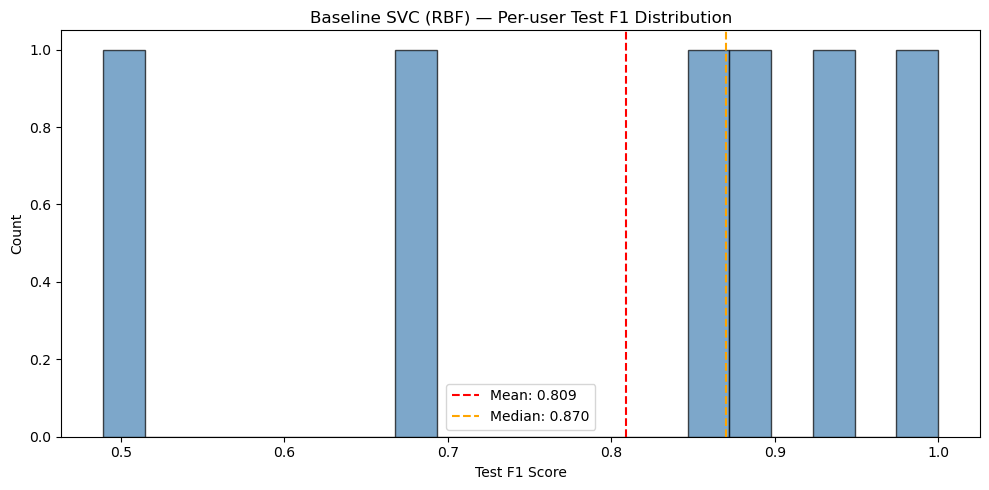

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(f1_values, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(np.mean(f1_values), color='red', linestyle='--', label=f'Mean: {np.mean(f1_values):.3f}')
ax.axvline(np.median(f1_values), color='orange', linestyle='--', label=f'Median: {np.median(f1_values):.3f}')
ax.set_xlabel('Test F1 Score')
ax.set_ylabel('Count')
ax.set_title('Baseline SVC (RBF) — Per-user Test F1 Distribution')
ax.legend()
plt.tight_layout()
plt.show()

## Step 2: GNN Model for General Users

Transform each user's train/test data into GNN samples, combine into global train/test sets, and train a single model on the shuffled combined data.

Architecture from 2.0, with aggressive anti-overfitting (test set has entirely unseen users):
- `ff_hidden_dim=64, gcn_hidden_dim=64, transformer_dim=64, transformer_heads=4`
- `dropout=0.5, drop_edge_rate=0.4` (heavy stochastic regularization)
- `gate_param init=0.0` (sigmoid=0.5, balanced — shortcut generalizes better to unseen users)
- `weight_decay=5e-3` (strong L2)
- `lr=3e-3` with 5-epoch linear warmup + cosine decay
- `epochs=60, batch_size=256, log_every_n_steps=300`

In [13]:
from gnn_models import (
    PretrainedEmbeddingLookup, RetweetDataset, RetweetGNN,
    soft_f1_loss, combined_loss, evaluate, train_model,
)

In [14]:
import pyarrow.parquet as pq

if USE_S3_STORAGE:
    import s3fs as _s3fs

import gc as _gc

def _compact_sample(s):
    """Convert sample lists to numpy arrays for ~10x memory reduction.
    RetweetDataset.get() handles numpy arrays identically to Python lists:
      - torch.tensor(np_array).t() works the same as torch.tensor(list_of_tuples).t()
      - len(np_array) returns N (correct emptiness check)
      - list(np_array) and set(np_array) work for neighbor/retweeted lookups
    """
    ei = s["edge_index"]
    if len(ei) > 0:
        edge_arr = np.array(ei, dtype=np.int32) if not isinstance(ei, np.ndarray) else ei
    else:
        edge_arr = np.empty((0, 2), dtype=np.int32)
    return {
        "central_user_id": int(s["central_user_id"]),
        "neighbor_ids": np.asarray(s["neighbor_ids"], dtype=np.int64),
        "retweeted_ids": np.asarray(s["retweeted_ids"], dtype=np.int64),
        "edge_index": edge_arr,
        "label": int(s["label"]),
    }

def _load_split_from_local(split_name):
    """Read a split directory of local parquet files into compact sample dicts."""
    split_dir = f"{LOCAL_GNN_PATH}/split={split_name}"
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(f"No local cache at {split_dir}")
    files = sorted(f for f in os.listdir(split_dir) if f.endswith('.parquet'))
    samples = []
    for fi, fname in enumerate(files):
        table = pq.read_table(os.path.join(split_dir, fname))
        central_ids = table.column('central_user_id').to_pylist()
        neighbor_ids = table.column('neighbor_ids').to_pylist()
        retweeted_ids = table.column('retweeted_ids').to_pylist()
        edge_srcs = table.column('edge_src').to_pylist()
        edge_dsts = table.column('edge_dst').to_pylist()
        labels = table.column('label').to_pylist()
        del table
        for i in range(len(central_ids)):
            src, dst = edge_srcs[i], edge_dsts[i]
            if src:
                edge_arr = np.column_stack([src, dst]).astype(np.int32)
            else:
                edge_arr = np.empty((0, 2), dtype=np.int32)
            samples.append({
                "central_user_id": central_ids[i],
                "neighbor_ids": np.array(neighbor_ids[i], dtype=np.int64),
                "retweeted_ids": np.array(retweeted_ids[i], dtype=np.int64),
                "edge_index": edge_arr,
                "label": labels[i],
            })
        del central_ids, neighbor_ids, retweeted_ids, edge_srcs, edge_dsts, labels
        if (fi + 1) % 5 == 0:
            _gc.collect()  # Explicit garbage collection after large data processing
            print(f"    {split_name}: {fi+1}/{len(files)} files loaded ({len(samples)} samples)")
    return samples

def _load_split_from_s3(split_name, fs):
    """Read a split directory of parquet files into compact sample dicts, file-by-file."""
    split_dir = f"{S3_GNN_BUCKET}/{S3_GNN_PREFIX}/split={split_name}"
    files = sorted(fs.ls(split_dir, detail=False))
    files = [f for f in files if f.endswith('.parquet')]
    samples = []
    for fi, fpath in enumerate(files):
        table = pq.read_table(fpath, filesystem=fs)
        central_ids = table.column('central_user_id').to_pylist()
        neighbor_ids = table.column('neighbor_ids').to_pylist()
        retweeted_ids = table.column('retweeted_ids').to_pylist()
        edge_srcs = table.column('edge_src').to_pylist()
        edge_dsts = table.column('edge_dst').to_pylist()
        labels = table.column('label').to_pylist()
        del table
        for i in range(len(central_ids)):
            src, dst = edge_srcs[i], edge_dsts[i]
            if src:
                edge_arr = np.column_stack([src, dst]).astype(np.int32)
            else:
                edge_arr = np.empty((0, 2), dtype=np.int32)
            samples.append({
                "central_user_id": central_ids[i],
                "neighbor_ids": np.array(neighbor_ids[i], dtype=np.int64),
                "retweeted_ids": np.array(retweeted_ids[i], dtype=np.int64),
                "edge_index": edge_arr,
                "label": labels[i],
            })
        del central_ids, neighbor_ids, retweeted_ids, edge_srcs, edge_dsts, labels
        if (fi + 1) % 5 == 0:
            _gc.collect()
            print(f"    {split_name}: {fi+1}/{len(files)} files loaded ({len(samples)} samples)")
    return samples

try:
    # Try loading from cache (S3 or local depending on USE_S3_STORAGE)
    if USE_S3_STORAGE:
        _fs = _s3fs.S3FileSystem()
        train_dir = f"{S3_GNN_BUCKET}/{S3_GNN_PREFIX}/split=train"
        if not _fs.exists(train_dir):
            raise FileNotFoundError(f"No cache at {train_dir}")
    else:
        train_dir = f"{LOCAL_GNN_PATH}/split=train"
        if not os.path.isdir(train_dir):
            raise FileNotFoundError(f"No local cache at {train_dir}")

    # Free large objects no longer needed when loading from cache
    for _v in ['user_data', 'graph', 'baseline_f1s', 'all_baseline_test_preds']:
        if _v in globals():
            del globals()[_v]
    _gc.collect()  # Explicit garbage collection after cache cleanup

    print(f"Loading GNN samples from {GNN_CACHE_PATH}...")
    if USE_S3_STORAGE:
        all_train_samples = _load_split_from_s3("train", _fs)
    else:
        all_train_samples = _load_split_from_local("train")
    print(f"  Train: {len(all_train_samples)}")
    _gc.collect()
    if USE_S3_STORAGE:
        all_test_samples = _load_split_from_s3("test", _fs)
    else:
        all_test_samples = _load_split_from_local("test")
    print(f"  Test: {len(all_test_samples)}")

    # Reconstruct user_test_samples from test samples keyed by central_user_id
    user_test_samples = {}
    for s in all_test_samples:
        uid = s["central_user_id"]
        user_test_samples.setdefault(uid, []).append(s)

    gnn_failed_users = []
    print(f"  Users with test samples: {len(user_test_samples)}")
    if USE_S3_STORAGE:
        del _fs
except Exception as _cache_err:    
    print(f"No S3 cache found ({_cache_err}), building from scratch...")
    # del _fs  # Explicitly delete filesystem object to free memory

    # ---------------------------------------------------------------
    # Build GNN samples with group-based train/test split:
    #   TRAIN: train data from TRAIN_GROUPS (u_train, au_train)
    #   TEST:  test data from TRAIN_GROUPS + ALL data from TEST_GROUPS
    # ---------------------------------------------------------------
    all_train_samples = []
    all_test_samples = []
    user_test_samples = {}  # uid -> list of test samples (for per-user eval later)
    gnn_failed_users = []

    processing_plan = []
    for group in TRAIN_GROUPS:
        for uid in user_data.get(group, {}):
            processing_plan.append((group, uid, "train_group"))
    for group in TEST_GROUPS:
        for uid in user_data.get(group, {}):
            processing_plan.append((group, uid, "test_group"))

    print(f"Processing {len(processing_plan)} users ({sum(1 for _,_,r in processing_plan if r=='train_group')} train-group, "
          f"{sum(1 for _,_,r in processing_plan if r=='test_group')} test-group)")

    t0 = time.time()
    for i, (group, uid, role) in enumerate(processing_plan):
        t_user = time.time()
        X_tr, X_te, y_tr, y_te = user_data[group][uid]
        try:
            train_samples, test_samples = create_gnn_train_val_samples(uid, graph, X_tr, y_tr, X_te, y_te)
            # Compact samples to numpy for memory efficiency
            train_samples = [_compact_sample(s) for s in train_samples]
            test_samples = [_compact_sample(s) for s in test_samples]

            if role == "train_group":
                all_train_samples.extend(train_samples)
                all_test_samples.extend(test_samples)
                user_test_samples[uid] = test_samples
            else:
                all_test_samples.extend(train_samples)
                all_test_samples.extend(test_samples)
                user_test_samples[uid] = train_samples + test_samples

        except Exception as e:
            gnn_failed_users.append((group, uid, str(e)))
            print(f"  Warning: Failed to transform user {uid} ({group}): {e}")
            continue

        elapsed = time.time() - t0
        user_time = time.time() - t_user
        avg_per_user = elapsed / (i + 1)
        remaining = avg_per_user * (len(processing_plan) - i - 1)
        n_tr = len(train_samples) if role == "train_group" else 0
        n_te = len(test_samples) if role == "train_group" else len(train_samples) + len(test_samples)
        print(f"  [{i+1:>3}/{len(processing_plan)}] {group}/{uid}  "
              f"+{n_tr} train / +{n_te} test  "
              f"({user_time:.1f}s | elapsed {elapsed:.0f}s | ETA {remaining:.0f}s)")

    total_time = time.time() - t0
    print(f"\nGNN dataset ready in {total_time:.1f}s ({total_time/len(processing_plan):.1f}s/user avg):")
    print(f"  Total train samples: {len(all_train_samples)}")
    print(f"  Total test samples:  {len(all_test_samples)}")
    print(f"  Users with test samples: {len(user_test_samples)}")
    print(f"  Failed users: {len(gnn_failed_users)}")


# Shuffle train samples so batches mix users
from random import shuffle as shuffle_list
shuffle_list(all_train_samples)

Loading GNN samples from ./experiments/v3_full_N8/gnn_samples...
  Train: 19692
  Test: 18439
  Users with test samples: 8


In [15]:
# Save GNN samples to parquet (S3 or local depending on USE_S3_STORAGE)
# PyArrow directly — no Spark/JVM overhead.
import gc
import pyarrow as pa
import pyarrow.parquet as pq

if USE_S3_STORAGE:
    import s3fs

# Free objects no longer needed — reclaim memory before the write
for _var in ['user_data', 'graph', 'processing_plan', 'user_test_samples']:
    if _var in dir():
        exec(f'del {_var}')
gc.collect()

CHUNK_SIZE = 10_000  # rows per parquet file — small to control peak memory

# PyArrow schema with nested list columns
arrow_schema = pa.schema([
    ('central_user_id', pa.int64()),
    ('neighbor_ids', pa.list_(pa.int64())),
    ('retweeted_ids', pa.list_(pa.int64())),
    ('edge_src', pa.list_(pa.int64())),
    ('edge_dst', pa.list_(pa.int64())),
    ('label', pa.int32()),
])

def samples_to_arrow_table(samples):
    """Convert a batch of sample dicts to a PyArrow Table, column-by-column to minimize peak memory."""
    n = len(samples)
    # Build and convert one column at a time to avoid holding all columns as Python lists simultaneously
    col_central = pa.array([int(s["central_user_id"]) for s in samples], type=pa.int64())
    col_label = pa.array([int(s["label"]) for s in samples], type=pa.int32())

    col_neighbors = pa.array([s["neighbor_ids"] for s in samples], type=pa.list_(pa.int64()))
    col_retweeted = pa.array([s["retweeted_ids"] for s in samples], type=pa.list_(pa.int64()))

    edge_src_data = []
    edge_dst_data = []
    for s in samples:
        ei = s["edge_index"]
        if len(ei) > 0:
            edge_src_data.append([e[0] for e in ei])
            edge_dst_data.append([e[1] for e in ei])
        else:
            edge_src_data.append([])
            edge_dst_data.append([])
    col_edge_src = pa.array(edge_src_data, type=pa.list_(pa.int64()))
    del edge_src_data
    col_edge_dst = pa.array(edge_dst_data, type=pa.list_(pa.int64()))
    del edge_dst_data

    return pa.table({
        'central_user_id': col_central,
        'neighbor_ids': col_neighbors,
        'retweeted_ids': col_retweeted,
        'edge_src': col_edge_src,
        'edge_dst': col_edge_dst,
        'label': col_label,
    })

def write_split_s3(samples, split_name, fs):
    """Write a split as chunked parquet files directly to S3."""
    split_dir = f"{S3_GNN_BUCKET}/{S3_GNN_PREFIX}/split={split_name}"
    if fs.exists(split_dir):
        fs.rm(split_dir, recursive=True)
    fs.mkdirs(split_dir, exist_ok=True)

    n_chunks = (len(samples) + CHUNK_SIZE - 1) // CHUNK_SIZE
    for chunk_idx in range(n_chunks):
        start = chunk_idx * CHUNK_SIZE
        end = min(start + CHUNK_SIZE, len(samples))
        table = samples_to_arrow_table(samples[start:end])
        out_path = f"{split_dir}/part-{chunk_idx:05d}.snappy.parquet"
        with fs.open(out_path, 'wb') as f:
            pq.write_table(table, f, compression='snappy')
        del table
        gc.collect()
        print(f"    {split_name} part {chunk_idx+1}/{n_chunks} written ({end - start} rows)")

def write_split_local(samples, split_name):
    """Write a split as chunked parquet files to local filesystem."""
    import shutil
    split_dir = f"{LOCAL_GNN_PATH}/split={split_name}"
    if os.path.isdir(split_dir):
        shutil.rmtree(split_dir)
    os.makedirs(split_dir, exist_ok=True)

    n_chunks = (len(samples) + CHUNK_SIZE - 1) // CHUNK_SIZE
    for chunk_idx in range(n_chunks):
        start = chunk_idx * CHUNK_SIZE
        end = min(start + CHUNK_SIZE, len(samples))
        table = samples_to_arrow_table(samples[start:end])
        out_path = f"{split_dir}/part-{chunk_idx:05d}.snappy.parquet"
        pq.write_table(table, out_path, compression='snappy')
        del table
        gc.collect()
        print(f"    {split_name} part {chunk_idx+1}/{n_chunks} written ({end - start} rows)")

print(f"Writing {len(all_train_samples)} train + {len(all_test_samples)} test samples...")
print(f"  Path: {GNN_CACHE_PATH}")
print(f"  Chunk size: {CHUNK_SIZE:,} rows/file")

if USE_S3_STORAGE:
    fs = s3fs.S3FileSystem()
    write_split_s3(all_train_samples, "train", fs)
    write_split_s3(all_test_samples, "test", fs)
else:
    write_split_local(all_train_samples, "train")
    write_split_local(all_test_samples, "test")
print(f"\n  Done! Saved to {GNN_CACHE_PATH}")

# Save failed users
if gnn_failed_users:
    failed_table = pa.table({
        'group': pa.array([str(g) for g, _, _ in gnn_failed_users]),
        'user_id': pa.array([str(u) for _, u, _ in gnn_failed_users]),
        'error': pa.array([str(e) for _, _, e in gnn_failed_users]),
    })
    if USE_S3_STORAGE:
        failed_path = f"{S3_GNN_BUCKET}/{S3_GNN_PREFIX}_failed_users/part-00000.parquet"
        fs.mkdirs(f"{S3_GNN_BUCKET}/{S3_GNN_PREFIX}_failed_users", exist_ok=True)
        with fs.open(failed_path, 'wb') as f:
            pq.write_table(failed_table, f)
    else:
        failed_dir = f"{LOCAL_GNN_PATH}_failed_users"
        os.makedirs(failed_dir, exist_ok=True)
        pq.write_table(failed_table, f"{failed_dir}/part-00000.parquet")
    print(f"  Saved {len(gnn_failed_users)} failed users")
else:
    print("  No failed users to save.")

Writing 19692 train + 18439 test samples...
  Path: ./experiments/v3_full_N8/gnn_samples
  Chunk size: 10,000 rows/file
    train part 1/2 written (10000 rows)
    train part 2/2 written (9692 rows)
    test part 1/2 written (10000 rows)
    test part 2/2 written (8439 rows)

  Done! Saved to ./experiments/v3_full_N8/gnn_samples
  No failed users to save.


In [16]:
import gc
gc.collect()
torch.cuda.empty_cache()

# Validation from test set (to detect overfitting to train distribution)
# Sample a fixed subset of test set as val — same size as before (~3500)
from random import Random
VAL_SIZE = 20000
val_rng = Random(42)  # fixed seed for reproducibility across runs
val_indices = val_rng.sample(range(len(all_test_samples)), min(VAL_SIZE, len(all_test_samples)))
val_indices_set = set(val_indices)
val_samples_final = [all_test_samples[i] for i in val_indices]

# All train samples used for training (no holdout from train)
train_samples_final = all_train_samples

print(f"Train: {len(train_samples_final)} samples (full train set)")
print(f"Val: {len(val_samples_final)} samples (sampled from test set, fixed seed)")
print(f"Test set (full, for final eval): {len(all_test_samples)} samples")

Train: 19692 samples (full train set)
Val: 18439 samples (sampled from test set, fixed seed)
Test set (full, for final eval): 18439 samples


In [17]:
# Anti-overfitting: strong regularization to prevent memorizing train users' graph patterns.
# Test set has entirely unseen users — model must generalize graph structure, not memorize it.
model = RetweetGNN(
    ff_hidden_dim=64,
    gcn_hidden_dim=64,
    transformer_dim=64,
    transformer_heads=4,
    embeddings_path=EMBEDDINGS_PATH,
    device=device,
    dropout=0.5,           # high dropout forces redundant representations that transfer
    drop_edge_rate=0.1,    # drop edges — prevents memorizing specific neighbor patterns
).to(device)

# Gate at 0.0 → sigmoid=0.5 (balanced start). Let the model earn GNN contribution.
# Shortcut head uses aggregate stats (rt_frac, node_count) which generalize better to unseen users.
# If GNN can't beat shortcut on val, gate will stay low — that's fine.
with torch.no_grad():
    model.gate_param.fill_(0.0)

In [18]:
# Classic early stopping: stop after this many checkpoints without val F1 improvement.
# Set to None to disable early stopping and train for all epochs.
PATIENCE = 20  # at log_every_n_steps=300, this means ~6000 steps without improvement

In [22]:
gc.collect()
torch.cuda.empty_cache()

In [24]:
# Train on combined shuffled data — anti-overfitting configuration:
#   - lr=3e-3 with 5-epoch linear warmup: prevents fast memorization in early steps
#   - weight_decay=5e-3: strong L2 prevents weight specialization
#   - dropout=0.5 + drop_edge=0.4: heavy stochastic regularization
#   - gate_param=0.0 (50/50): shortcut generalizes better; GNN must earn its contribution

import sys
from datetime import datetime
from contextlib import contextmanager

class TeeLogger:
    """Tee stdout to both the original stream and a timestamped log file."""
    def __init__(self, log_path, original_stdout):
        self._original = original_stdout
        self._file = open(log_path, "a", buffering=1)  # line-buffered
        self._line_buffer = ""

    def write(self, msg):
        self._original.write(msg)
        # Add timestamp at the start of each complete line
        for char in msg:
            if char == "\n":
                timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                self._file.write(f"[{timestamp}] {self._line_buffer}\n")
                self._line_buffer = ""
            else:
                self._line_buffer += char

    def flush(self):
        self._original.flush()
        self._file.flush()

    def close(self):
        # Flush any remaining buffer
        if self._line_buffer:
            timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            self._file.write(f"[{timestamp}] {self._line_buffer}\n")
            self._line_buffer = ""
        self._file.close()

@contextmanager
def tee_to_log(log_path):
    """Context manager that tees all stdout to a timestamped log file."""
    original_stdout = sys.stdout
    tee = TeeLogger(log_path, original_stdout)
    sys.stdout = tee
    try:
        yield log_path
    finally:
        sys.stdout = original_stdout
        tee.close()
        print(f"Training log saved to: {log_path}")

TRAINING_LOG_PATH = f"{EXPERIMENT_DIR}/training.log"

with tee_to_log(TRAINING_LOG_PATH):
    model, history = train_model(
        model=model,
        raw_train_samples=train_samples_final,
        raw_val_samples=val_samples_final,
        experiment_dir=EXPERIMENT_DIR,
        epochs=60,
        # batch_size=128,
        batch_size=256,
        device=device,
        lr=3e-3,
        log_every_n_steps=300,
        patience=PATIENCE,
        lr_warmup_epochs=5,
        weight_decay=1e-3,
        resume=False,
    )

Training on cuda | 19692 train / 18439 val samples
Trainable params: 56,439
Steps/epoch: 153 | Total steps: 9180 | Logging every 300 steps
LR warmup: 5 epochs | weight_decay: 0.001 | patience: 20


Epoch 1/60:   0%|          | 0/153 [00:00<?, ?it/s]

Training log saved to: ./experiments/v3_full_N8/training.log


[HAMI-core ERROR (pid:217 thread=139862702472512 allocator.c:52)]: Device 0 OOM 7266763776 / 6442450944
[HAMI-core ERROR (pid:217 thread=139862702472512 allocator.c:52)]: Device 0 OOM 7266763776 / 6442450944
[HAMI-core ERROR (pid:217 thread=139862702472512 allocator.c:52)]: Device 0 OOM 7040271360 / 6442450944


OutOfMemoryError: CUDA out of memory. Tried to allocate 880.00 MiB. GPU 0 has a total capacity of 6.00 GiB of which 309.87 MiB is free. Process 1784995 has 5.74 GiB memory in use. Of the allocated memory 5.31 GiB is allocated by PyTorch, and 160.44 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)